<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
import requests
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
r = requests.get(url)
with open('survey-data.csv', 'wb') as f:
    f.write(r.content)


# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



In [4]:
pie_db = df[['DatabaseWantToWorkWith']]
pie_db = pie_db.dropna()
pie_db['DatabaseWantToWorkWith'] = pie_db['DatabaseWantToWorkWith'].str.split(';')
pie_db = pie_db.explode('DatabaseWantToWorkWith').reset_index(drop = True)
pie_db

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB
3,MySQL
4,PostgreSQL
...,...
127434,PostgreSQL
127435,SQLite
127436,MongoDB
127437,MySQL


In [5]:
pie_db['DatabaseWantToWorkWith'].value_counts().head(5)

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

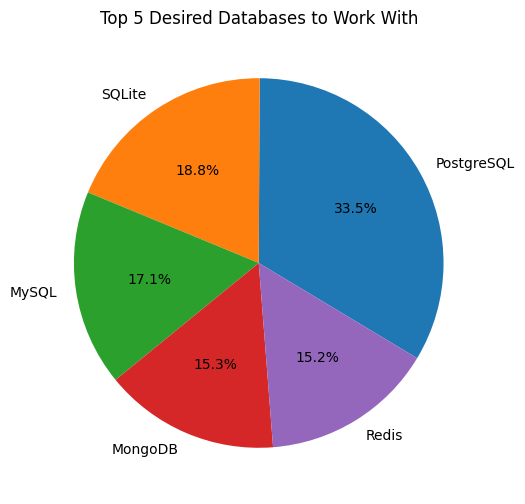

In [6]:
pie = pie_db['DatabaseWantToWorkWith'].value_counts()

plt.figure(figsize = (6,6))
plt.pie(x = pie.head(5),
        autopct = '%1.1f%%',
        labels = pie.head().index,
        startangle = -31)
plt.title('Top 5 Desired Databases to Work With')
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



In [7]:
pie_dev = df[['DevType']]
pie_dev = pie_dev.dropna()
pie_dev['DevType'].value_counts().head(5)

DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Name: count, dtype: int64

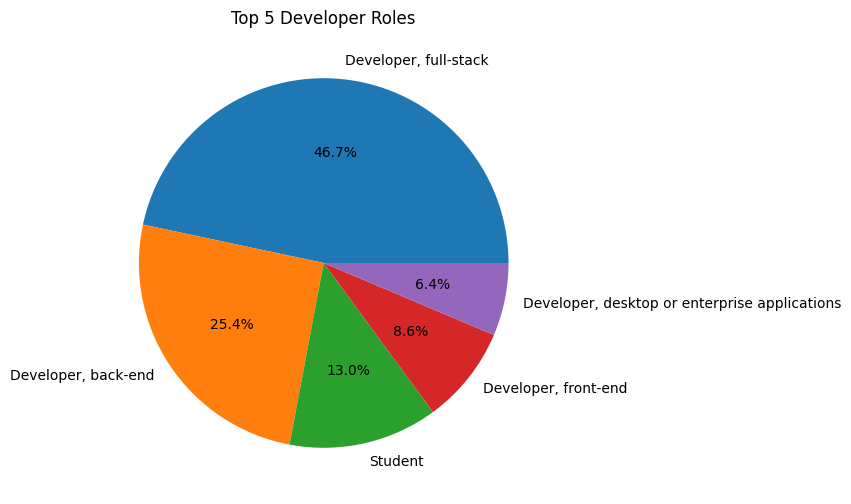

In [8]:
pie = pie_dev['DevType'].value_counts().head(5)
plt.figure(figsize = (6,6))
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top 5 Developer Roles')
plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional use` column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [9]:
pie_OS = df[['OpSysProfessional use']]
pie_OS = pie_OS.dropna()
pie_OS

,OpSysProfessional use
1,MacOS
2,Windows
6,MacOS
7,MacOS
8,MacOS
...,...
65414,Windows
65421,Ubuntu
65431,Debian;iOS;iPadOS;MacOS;Other Linux-based;Ubun...
65435,Fedora;Other Linux-based;Ubuntu


In [10]:
pie_OS['OS Pro'] = pie_OS['OpSysProfessional use'].str.split(';') # split the lists at ; into new column
pie_OS = pie_OS.explode('OS Pro')
pie_OS = pie_OS.drop('OpSysProfessional use', axis = 1)
pie_OS = pie_OS.reset_index(drop = True)
pie_OS

,OS Pro
0,MacOS
1,Windows
2,MacOS
3,MacOS
4,MacOS
...,...
104238,Fedora
104239,Other Linux-based
104240,Ubuntu
104241,MacOS


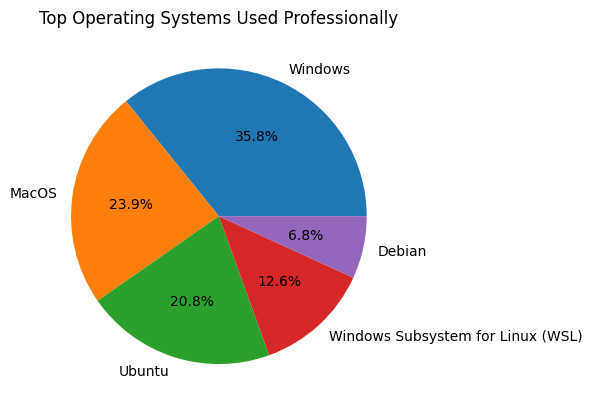

In [11]:
pie = pie_OS.value_counts(subset = 'OS Pro').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top Operating Systems Used Professionally')
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



In [12]:
pie_lang = df[['LanguageHaveWorkedWith']]
pie_lang = pie_lang.dropna()
pie_lang['Lang'] = pie_lang['LanguageHaveWorkedWith'].str.split(';') # splitting on ; into new column 'Lang'
pie_lang = pie_lang.explode('Lang')
pie_lang = pie_lang.drop('LanguageHaveWorkedWith', axis = 1)
pie_lang = pie_lang.reset_index(drop = True)
pie_lang

,Lang
0,Bash/Shell (all shells)
1,Go
2,HTML/CSS
3,Java
4,JavaScript
...,...
322228,Java
322229,JavaScript
322230,PHP
322231,Python


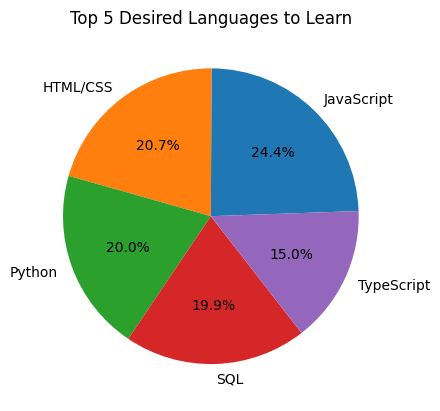

In [13]:
pie = pie_lang.value_counts(subset = 'Lang').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%',
        startangle = 2)
plt.title('Top 5 Desired Languages to Learn')
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



In [14]:
pie_collab_tool = df[['NEWCollabToolsHaveWorkedWith']]
pie_collab_tool = pie_collab_tool.dropna()
pie_collab_tool

,NEWCollabToolsHaveWorkedWith
1,PyCharm;Visual Studio Code;WebStorm
2,Visual Studio
4,Vim
5,Nano;Vim;Visual Studio Code;Xcode
6,RStudio
...,...
65414,Android Studio;Jupyter Notebook/JupyterLab;Vis...
65421,Sublime Text;Visual Studio Code
65431,DataGrip;IntelliJ IDEA;PyCharm;Rider;Sublime T...
65435,Vim;Visual Studio Code


In [15]:
pie_collab_tool['CollabTools'] = pie_collab_tool['NEWCollabToolsHaveWorkedWith'].str.split(';')
pie_collab_tool = pie_collab_tool.drop('NEWCollabToolsHaveWorkedWith', axis = 1)
pie_collab_tool = pie_collab_tool.explode('CollabTools')
pie_collab_tool = pie_collab_tool.reset_index(drop = True)
pie_collab_tool

,CollabTools
0,PyCharm
1,Visual Studio Code
2,WebStorm
3,Visual Studio
4,Vim
...,...
196231,WebStorm
196232,Xcode
196233,Vim
196234,Visual Studio Code


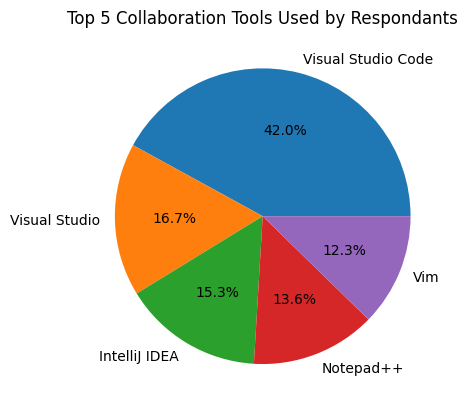

In [16]:
pie = pie_collab_tool.value_counts(subset = 'CollabTools').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top 5 Collaboration Tools Used by Respondants')
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



In [17]:
pie_lang_admired = df[['LanguageAdmired']]
pie_lang_admired = pie_lang_admired.dropna()
pie_lang_admired['LangAdmired'] = pie_lang_admired['LanguageAdmired'].str.split(';')
pie_lang_admired = pie_lang_admired.drop('LanguageAdmired', axis = 1)
pie_lang_admired = pie_lang_admired.explode('LangAdmired').reset_index(drop = True)
pie_lang_admired

,LangAdmired
0,Bash/Shell (all shells)
1,Go
2,HTML/CSS
3,Java
4,JavaScript
...,...
189198,Rust
189199,SQL
189200,JavaScript
189201,Python


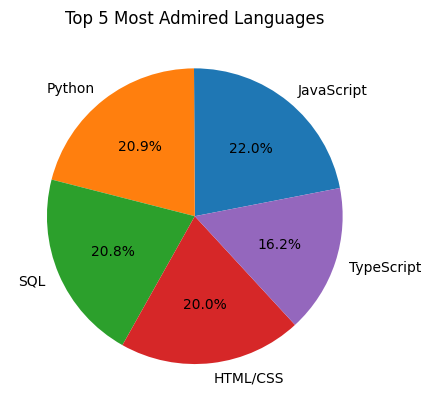

In [18]:
pie = pie_lang_admired.value_counts('LangAdmired').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%',
        startangle = 11)
plt.title('Top 5 Most Admired Languages')
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently Using` column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [19]:
pie_AI_current = df[['AIToolCurrently Using']]
pie_AI_current = pie_AI_current.dropna()
pie_AI_current

,AIToolCurrently Using
3,Learning about a codebase;Project planning;Wri...
5,Writing code;Debugging and getting help
7,Writing code;Debugging and getting help;Search...
9,Search for answers
10,Learning about a codebase;Writing code;Documen...
...,...
65426,Learning about a codebase;Writing code;Search ...
65427,Writing code;Debugging and getting help;Search...
65429,Writing code;Debugging and getting help
65430,Writing code;Documenting code;Debugging and ge...


In [20]:
pie_AI_current['AI_Current'] = pie_AI_current['AIToolCurrently Using'].str.split(';')
pie_AI_current = pie_AI_current.drop('AIToolCurrently Using', axis = 1)
pie_AI_current = pie_AI_current.explode('AI_Current').reset_index(drop = True)
pie_AI_current

,AI_Current
0,Learning about a codebase
1,Project planning
2,Writing code
3,Documenting code
4,Debugging and getting help
...,...
135126,Project planning
135127,Writing code
135128,Documenting code
135129,Search for answers


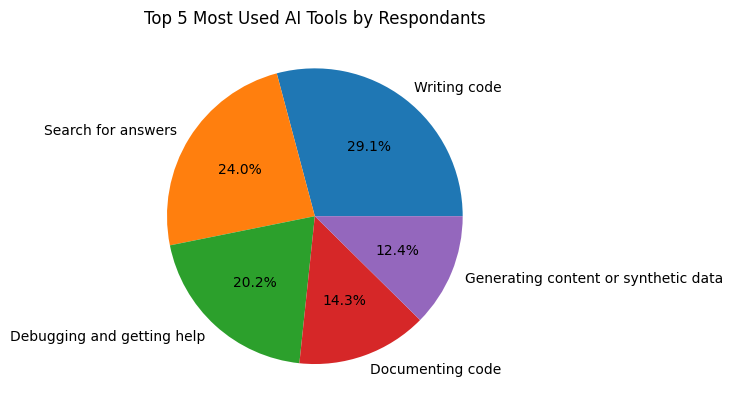

In [21]:
pie = pie_AI_current.value_counts(subset = 'AI_Current').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top 5 Most Used AI Tools by Respondants')
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



In [22]:
pie_webframe = df[['WebframeWantToWorkWith']]
pie_webframe = pie_webframe.dropna()
pie_webframe

,WebframeWantToWorkWith
1,Express;Htmx;Node.js;React;Remix
2,ASP.NET CORE
3,jQuery;Next.js;Node.js;React
5,Node.js
7,Next.js;React
...,...
65408,Vue.js
65409,jQuery;Next.js;Node.js;React;WordPress
65414,Deno
65431,Angular;ASP.NET;ASP.NET CORE;Node.js;Spring Boot


In [23]:
pie_webframe['WebframeWant'] = pie_webframe['WebframeWantToWorkWith'].str.split(';')
pie_webframe = pie_webframe.drop('WebframeWantToWorkWith', axis = 1)
pie_webframe = pie_webframe.explode('WebframeWant').reset_index(drop = True)
pie_webframe

,WebframeWant
0,Express
1,Htmx
2,Node.js
3,React
4,Remix
...,...
133252,Django
133253,Express
133254,Next.js
133255,Node.js


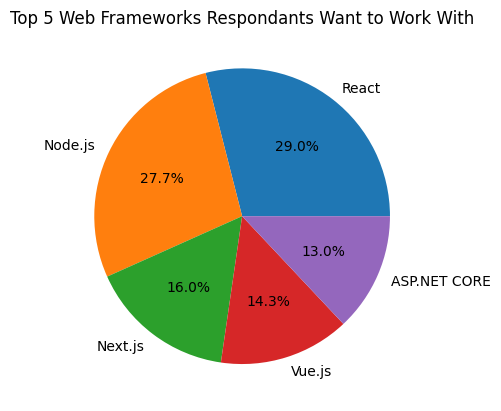

In [24]:
pie = pie_webframe.value_counts(subset = 'WebframeWant').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top 5 Web Frameworks Respondants Want to Work With')
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



In [25]:
pie_embedded_want = df[['EmbeddedWantToWorkWith']]
pie_embedded_want = pie_embedded_want.dropna()
pie_embedded_want

,EmbeddedWantToWorkWith
2,Rasberry Pi
4,CMake;Rasberry Pi
5,Rasberry Pi
15,Rasberry Pi
20,Rasberry Pi
...,...
65268,Arduino;LLVM's Clang;Rasberry Pi
65300,Rasberry Pi
65333,Rasberry Pi
65371,Rasberry Pi


In [26]:
pie_embedded_want['Embedded_Want'] = pie_embedded_want['EmbeddedWantToWorkWith'].str.split(';')
pie_embedded_want = pie_embedded_want.drop('EmbeddedWantToWorkWith', axis = 1)
pie_embedded_want = pie_embedded_want.explode('Embedded_Want').reset_index(drop = True)
pie_embedded_want

,Embedded_Want
0,Rasberry Pi
1,CMake
2,Rasberry Pi
3,Rasberry Pi
4,Rasberry Pi
...,...
42951,Rasberry Pi
42952,Rasberry Pi
42953,Cargo
42954,GNU GCC


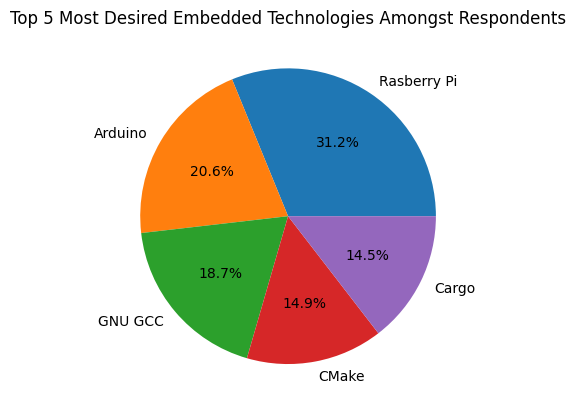

In [27]:
pie = pie_embedded_want.value_counts(subset = 'Embedded_Want').head()
plt.pie(x = pie,
        labels = pie.index,
        autopct = '%1.1f%%')
plt.title('Top 5 Most Desired Embedded Technologies Amongst Respondents')
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
